In [1]:
import tensorflow as tf
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

In [6]:
wine = load_wine()
x = wine.data   #x debe ser 2d
y = wine.target #y debe ser 1d
print(x.shape) #asegurarse que x es 2d
print(y.shape) #y es 1d

(178, 13)
(178,)


In [8]:
print("Dato",x[0])
print("Etiqueta",y[0])
print("Nombre Etiqueta",wine.target_names[y[0]])
print("Caràcteristicas del dataset", wine.feature_names)
print("cant. de caracterìsticas (Para input layer:)", len(wine.feature_names))
print("targets:", len(wine.target_names))
print(" cant. de etiquetas (Para output layer):", len(wine.target_names))

Dato [1.423e+01 1.710e+00 2.430e+00 1.560e+01 1.270e+02 2.800e+00 3.060e+00
 2.800e-01 2.290e+00 5.640e+00 1.040e+00 3.920e+00 1.065e+03]
Etiqueta 0
Nombre Etiqueta class_0
Caràcteristicas del dataset ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
cant. de caracterìsticas (Para input layer:) 13
targets: 3
 cant. de etiquetas (Para output layer): 3


In [9]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state= 42)

In [10]:
model= tf.keras.models.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(13,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

C:\Users\Alumno\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

In [12]:
model.fit(x_train, y_train, epochs = 100)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 137.2262 
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 111.9817 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 102.8089 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 92.7070  
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 86.2814  
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 78.6370 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 72.7682 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 66.4073 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 61.2746 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 56.9314 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 52.3626 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 47.9020 
Epoch 13/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 43.6488 
Epoch 14/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 39.1655 
Epoch 15/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 35.2009 

In [16]:
print('---Predicción Individual---')
muestra= x_test[0].reshape(1,13)
print('Muestra seleccionada: ', muestra)
etiqueta= y_test[0]
print('Etiqueta de la muestra: ', etiqueta)
prediccion= model.predict(muestra)
print("Probabilidades reales de nuestra salida",prediccion)
print("Etiqueta con la probabilidad máxima",prediccion.argmax(1))


---Predicción Individual---
Muestra seleccionada:  [[1.364e+01 3.100e+00 2.560e+00 1.520e+01 1.160e+02 2.700e+00 3.030e+00
  1.700e-01 1.660e+00 5.100e+00 9.600e-01 3.360e+00 8.450e+02]]
Etiqueta de la muestra:  0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Probabilidades reales de nuestra salida [[0.44372642 0.22858626 0.32768738]]
Etiqueta con la probabilidad máxima [0]


In [17]:
print('---Predicción Total---')
predicciones= model.predict(x_test).argmax(1)
print('Predicciones')
print(predicciones)
print('Etiquetas reales')
print(y_test)

---Predicción Total---
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Predicciones
[0 0 2 0 1 0 1 2 1 0 0 1 0 1 0 1 1 1 0 1 0 1 1 2 2 2 1 1 1 0 0 1 2 0 0 0]
Etiquetas reales
[0 0 2 0 1 0 1 2 1 2 0 2 0 1 0 1 1 1 0 1 0 1 1 2 2 2 1 1 1 0 0 1 2 0 0 0]


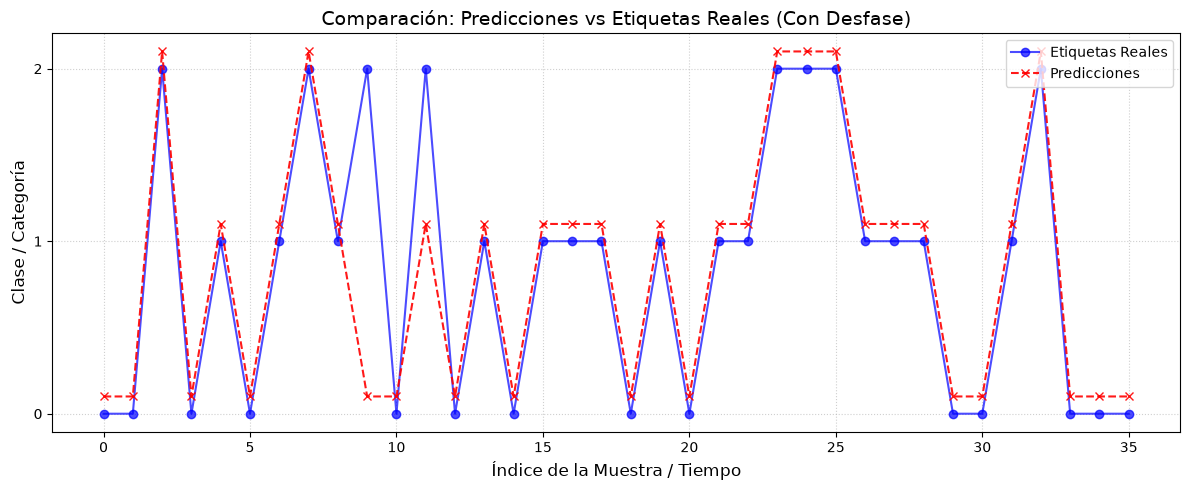

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# --- Tus variables originales ---
# predicciones = model.predict(x_test).argmax(1)
# y_test = ...

# Graficamos solo las primeras N muestras para que el gráfico sea legible
# (Si graficas miles de puntos a la vez, las líneas se verán como un bloque sólido)
muestras_a_mostrar = 50 

real_subset = y_test[:muestras_a_mostrar]
pred_subset = predicciones[:muestras_a_mostrar]

# Creamos el eje X basado en la cantidad de muestras
X_indices = np.arange(len(real_subset))

plt.figure(figsize=(12, 5))

# 1. Línea Real (en su posición original)
plt.plot(X_indices, real_subset, label='Etiquetas Reales', 
         color='blue', marker='o', linestyle='-', alpha=0.7)

# 2. Línea de Predicción (le sumamos un pequeño desfase, ej: 0.1)
desfase = 0.1
plt.plot(X_indices, pred_subset + desfase, label='Predicciones', 
         color='red', marker='x', linestyle='--', alpha=0.9)

# Personalización del gráfico
plt.title('Comparación: Predicciones vs Etiquetas Reales (Con Desfase)', fontsize=14)
plt.xlabel('Índice de la Muestra / Tiempo', fontsize=12)
plt.ylabel('Clase / Categoría', fontsize=12)

# Forzamos a que el eje Y muestre solo números enteros (las clases reales)
plt.yticks(np.unique(y_test))

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()
